In [206]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from importlib import reload
import src.train
reload(src.train)
import src.scp_core
reload(src.scp_core)

from src.train import train
from src.scp_core import uniform_sample_bright_side, rwm_bright_side, SCP, rwm_stepout_dark_side

In [207]:
d = 5
latitude = 1.5
scp = SCP(d, latitude=latitude)

## Uniform on sphere

In [209]:
logp_sphere = lambda _: 0.
key1, key2 = jax.random.split(jax.random.key(0))
x0 = uniform_sample_bright_side(d, latitude, key1, n=1)[0]
rwm_samples, rwm_accepts = rwm_bright_side(logp_sphere, x0, latitude, key=key2, nsample=1000_000, stepsize=100)
print(rwm_accepts.mean())
teleport_samples, teleport_accepts = rwm_stepout_dark_side(logp_sphere, x0, latitude, key=key2, nsample=1000_000, stepsize=100)
print(teleport_accepts.mean())

0.866128
1.0


In [210]:
teleport_samples[:, -1].max()

Array(1.4999962, dtype=float32)

In [211]:
uniform_samples = uniform_sample_bright_side(d, latitude, jax.random.key(0), rwm_samples.shape[0])

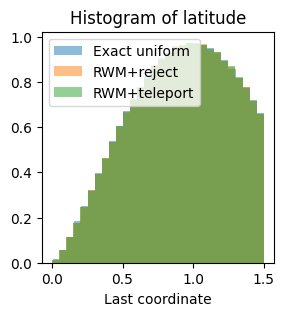

In [213]:
plt.figure(figsize=(3, 3))
plt.hist(uniform_samples[:, -1], 30, density=True, alpha=.5, label='Exact uniform')
plt.hist(rwm_samples[:, -1], 30, density=True, alpha=.5, label='RWM+reject')
plt.hist(teleport_samples[:, -1], 30, density=True, alpha=.5, label='RWM+teleport')
plt.xlabel('Last coordinate')
plt.title('Histogram of latitude')
plt.legend(loc='upper left')
plt.show()

Specify target density

In [214]:
_observer = jnp.linspace(-1, 1, d)
_observer *= jnp.sqrt((0.9 - (1 - latitude)**2) / jnp.sum(_observer**2))
print(jnp.sum(_observer**2) + (latitude - 1)**2)
target_params = scp.inverse_transform_params(_observer, 
                                             shift=jnp.zeros(d), 
                                             scale=1.)

def target_logp(x):
    return scp.log_prob(target_params, x)

0.9


Visualize target distribution

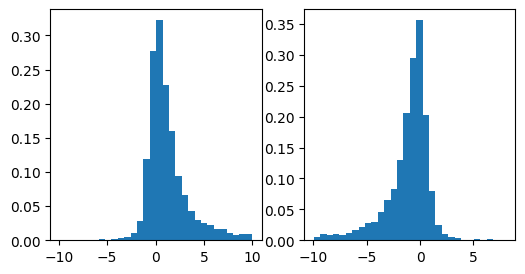

In [215]:
key = jax.random.key(0)
exact_samples = scp.sample(target_params, key, n=5000)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True)
ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True)
plt.show()

In [216]:
opt_params, losses = scp.minimize_reverse_kl(target_logp)

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 11841.33it/s]


In [217]:
mcmc_samples, accept_prob = scp.rwm_bright_side(target_logp, target_params, seed=1, stepsize=10, nsample=100_000, burnin=500, thinning=10)

In [219]:
exact_samples = scp.sample(target_params, key, n=mcmc_samples.shape[0])

In [220]:
jnp.quantile(exact_samples[:, 0], jnp.array([0.01, 0.99]))

Array([-2.7542088, 52.100105 ], dtype=float32)

In [222]:
for q in [0.8, 0.9, 0.95, 0.99]:
    print(q, jnp.mean(mcmc_samples[:, 0] > q), jnp.mean(exact_samples[:, 0] > q))

for q in [1.4, 1.45, 1.49]:
    print(q, jnp.mean(mcmc_samples[:, -1] > q), jnp.mean(exact_samples[:, -1] > q))

0.8 0.48139998 0.4955
0.9 0.45569998 0.4703
0.95 0.4445 0.4581
0.99 0.43559998 0.45029998
1.4 0.0321 0.0307
1.45 0.0308 0.0284
1.49 0.029199999 0.0267


In [223]:
for q in [-10, -15, -20, -25]:
    print(q, jnp.mean(mcmc_samples[:, -1] < q), jnp.mean(exact_samples[:, -1] < q))

-10 0.0486 0.053799998
-15 0.0336 0.0359
-20 0.025999999 0.0285
-25 0.0209 0.0211


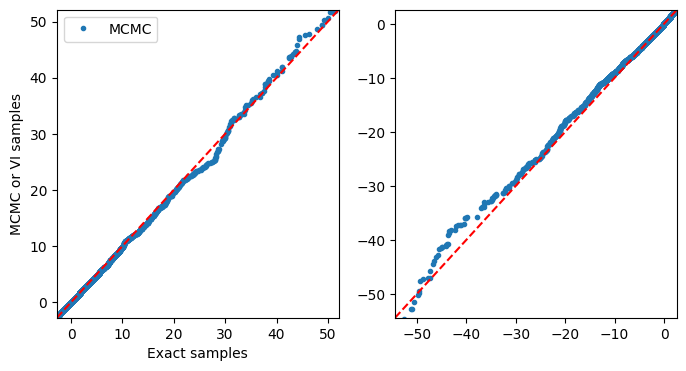

In [229]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i, j in enumerate([0, d-1]):
    exact_sorted = jnp.sort(exact_samples[:, j])
    mcmc_sorted = jnp.sort(mcmc_samples[:, j])
    # vi_sorted = jnp.sort(transformed_samples[:, j])
    ax[i].plot(exact_sorted, mcmc_sorted, '.', label='MCMC')
    # ax[i].plot(exact_sorted, vi_sorted, '.', label='VI')
    
    qs = jnp.quantile(exact_sorted, jnp.array([0.01, 0.99]))
    ax[i].set_xlim(qs)
    ax[i].set_ylim(qs)
    ax[i].plot(qs, qs, 'r--')  # Reference line for y=x
# ax[1].set_xlim(-12., 5)
# ax[1].set_ylim(-12., 5)
ax[0].set_xlabel('Exact samples')
ax[0].set_ylabel('MCMC or VI samples')
ax[0].legend()

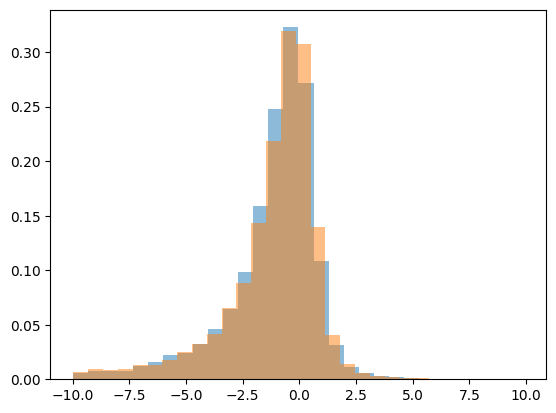

In [231]:
plt.hist(mcmc_samples[abs(mcmc_samples[:, -1]) < 10, -1], 30, density=True, alpha=.5)
plt.hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)
plt.show()

Initialize parameters and samples

In [49]:
seed = 1
ntrain = 5000
X = uniform_sample_bright_side(d, latitude, jax.random.key(seed), n=ntrain)

params = {
    'observer': jnp.zeros(d),
    'shift': jnp.zeros(d),
    'scale': 0.
}

Define loss function as the reverse KL

In [50]:
@jax.jit
def loss_fn(params, X):
    return scp.reverse_kl(params, target_logp, X)

opt_params, losses = train(lambda params: loss_fn(params, X), params, learning_rate=0.01, max_iter=1000)

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 1126.76it/s]


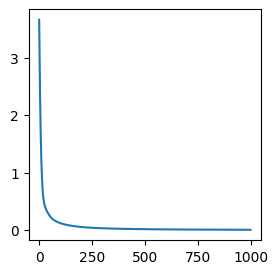

In [51]:
plt.figure(figsize=(3, 3))
plt.plot(losses)

In [52]:
scp.transform_params(opt_params), scp.transform_params(target_params)

((Array([-0.39677775, -0.29745167, -0.21773434, -0.12796776, -0.04244794,
          0.04735612,  0.12779334,  0.20628348,  0.304104  ,  0.37384567],      dtype=float32),
  Array([ 0.02860155,  0.01878378,  0.00799526,  0.00561994,  0.00164215,
          0.00325023, -0.01334992, -0.03175564, -0.03113881, -0.04213291],      dtype=float32),
  Array(0.99071044, dtype=float32)),
 (Array([-0.41450956, -0.32239634, -0.23028311, -0.13816984, -0.04605663,
          0.04605664,  0.13816987,  0.23028311,  0.32239634,  0.41450956],      dtype=float32),
  Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
  Array(1., dtype=float32, weak_type=True)))

In [53]:
transformed_samples = scp.projection(opt_params, X)

Visualize transformed samples with the learned parameters

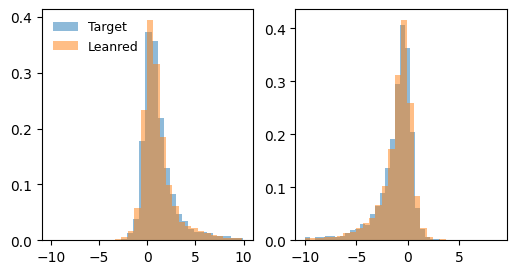

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Target')
ax[0].hist(transformed_samples[abs(transformed_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Leanred')

ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)
ax[1].hist(transformed_samples[abs(transformed_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)

ax[0].legend(loc='upper left', fontsize=9, frameon=False)
plt.show()

In [64]:
logp_sphere = scp.transform_target(target_logp, opt_params)

nsample = 100_000
burnin = 500
x0 = jnp.zeros(d+1)
mcmc_samples_sphere, accepts = rwm_bright_side(logp_sphere, x0, latitude, key=jax.random.key(10), nsample=nsample+burnin, stepsize=0.5)

In [65]:
mcmc_samples = scp.projection(opt_params, mcmc_samples_sphere[burnin:])

In [66]:
accepts.mean()

Array(0.95410943, dtype=float32)

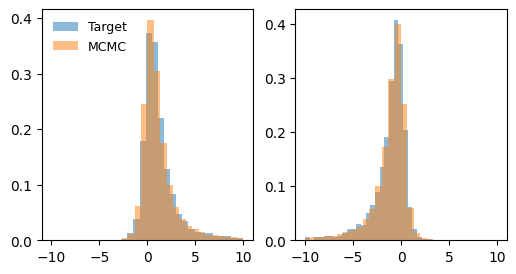

In [67]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Target')
ax[0].hist(mcmc_samples[abs(mcmc_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='MCMC')

ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)
ax[1].hist(mcmc_samples[abs(mcmc_samples[:, -1]) < 10, -1], 30, density=True, alpha=.5)

ax[0].legend(loc='upper left', fontsize=9, frameon=False)
plt.show()

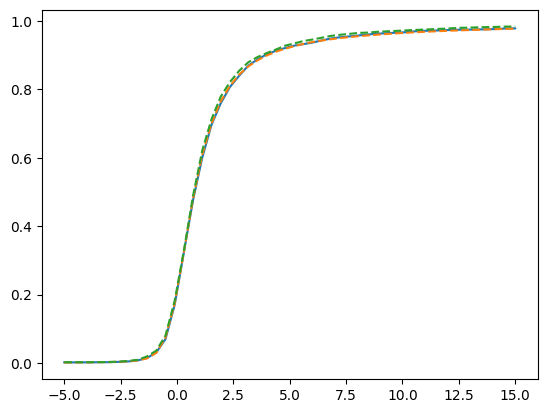

In [68]:
xx = jnp.linspace(-5, 15, 50)
plt.plot(xx, [jnp.mean(exact_samples[:, 0] <= x) for x in xx])
plt.plot(xx, [jnp.mean(mcmc_samples[:, 0] <= x) for x in xx], ls='--')
plt.plot(xx, [jnp.mean(transformed_samples[:, 0] <= x) for x in xx], ls='--')

In [69]:
jnp.quantile(exact_samples[:, 0], jnp.array([0.01, 0.99]))

Array([-1.5623236, 35.094204 ], dtype=float32)

In [71]:
exact_samples = scp.sample(target_params, key, n=mcmc_samples.shape[0])

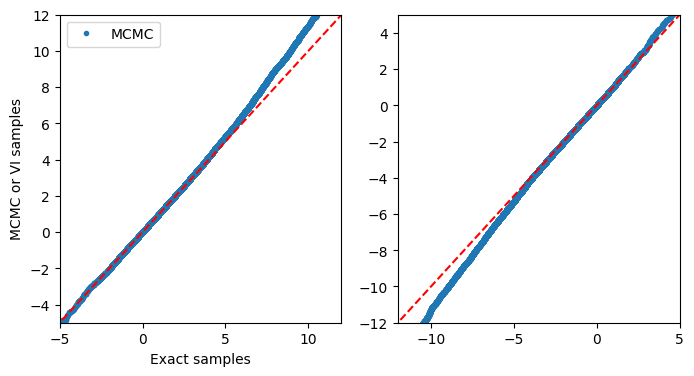

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i, j in enumerate([0, d-1]):
    exact_sorted = jnp.sort(exact_samples[:, j])
    mcmc_sorted = jnp.sort(mcmc_samples[:, j])
    # vi_sorted = jnp.sort(transformed_samples[:, j])
    ax[i].plot(exact_sorted, mcmc_sorted, '.', label='MCMC')
    # ax[i].plot(exact_sorted, vi_sorted, '.', label='VI')
    ax[i].plot([-15, 15], [-15, 15], 'r--')  # Reference line for y=x

ax[0].set_xlim(-5., 12)
ax[0].set_ylim(-5., 12)
ax[1].set_xlim(-12., 5)
ax[1].set_ylim(-12., 5)
ax[0].set_xlabel('Exact samples')
ax[0].set_ylabel('MCMC or VI samples')
ax[0].legend()

## Skewed $t$

In [232]:
import numpy as np
from scipy.stats import jf_skew_t , skewcauchy, cauchy

In [233]:
a = jnp.linspace(-0.9, 0.9, 10)
x = skewcauchy(jnp.linspace(-0.9, 0.9, 10)).rvs((1000, 10))

In [234]:
d = 5
a = np.linspace(1, 2, d)
b = np.linspace(2, 1, d)
target_skewt = jf_skew_t(a, b)
exact_samples = target_skewt.rvs((5000, d))

def target_logp(x):
    # return target_skewt.logpdf(x).sum(-1)
    logp = (a + 0.5) * jnp.log(1 + x / jnp.sqrt(a + b + x**2)) + (b + .5) * jnp.log(1 - x / jnp.sqrt(a + b + x**2))
    return logp.sum(-1)

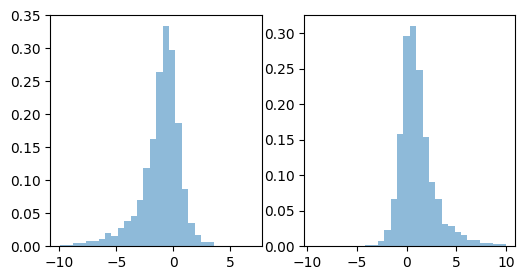

In [235]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5)
ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)
plt.show()

In [236]:
seed = 4
ntrain = 5000
latitude = 1.8 
scp = SCP(d, latitude)
X = uniform_sample_bright_side(d, latitude, jax.random.key(seed), n=ntrain)

params = {
    'observer': jnp.zeros(d),
    'shift': jnp.zeros(d),
    'scale': 0.
}

@jax.jit
def loss_fn(params, X):
    return scp.reverse_kl(params, target_logp, X)

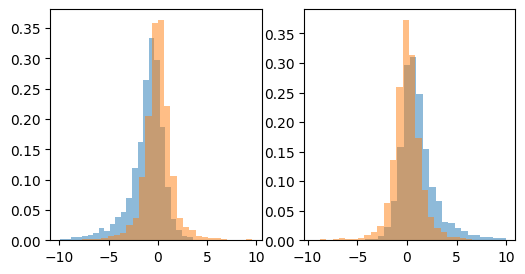

In [237]:
initial_samples = scp.projection(params, X)
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5)
ax[0].hist(initial_samples[abs(initial_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5)
ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)
ax[1].hist(initial_samples[abs(initial_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)
plt.show()

In [238]:
opt_params, losses = train(lambda params: loss_fn(params, X), params, learning_rate=0.01, max_iter=1000)

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 2158.42it/s]


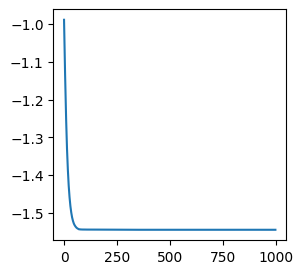

In [239]:
plt.figure(figsize=(3, 3))
plt.plot(losses)

In [240]:
jnp.sum(scp.transform_params(opt_params)[0]**2) + (latitude - 1)**2

Array(0.73698264, dtype=float32)

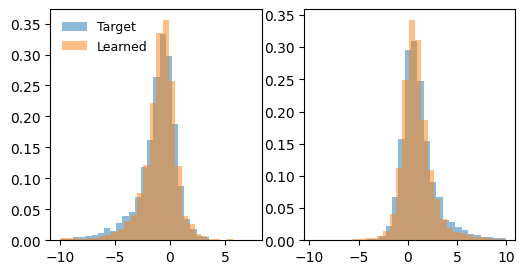

In [241]:
transformed_samples = scp.projection(opt_params, X)
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Target')
ax[0].hist(transformed_samples[abs(transformed_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Learned')
ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5, label='Target')
ax[1].hist(transformed_samples[abs(transformed_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5, label='Learned')
ax[0].legend(loc='upper left', fontsize=9, frameon=False)
plt.show()

In [272]:
logp_sphere = scp.transform_target(target_logp, opt_params)

nsample = 1000_000
burnin = 500
key, subkey = jax.random.split(jax.random.key(1))
x0 = uniform_sample_bright_side(d, latitude, subkey, n=1)[0]
key, subkey = jax.random.split(key)
mcmc_samples_sphere, accepts = rwm_stepout_dark_side(logp_sphere, x0, latitude, key=subkey, nsample=nsample+burnin, stepsize=5)
print(accepts.mean())

0.55546725


In [273]:
mcmc_samples = scp.projection(opt_params, mcmc_samples_sphere[burnin:])
mcmc_samples = mcmc_samples[::10]

In [274]:
exact_samples = target_skewt.rvs((mcmc_samples.shape[0], d))
vi_samples = scp.projection(opt_params, uniform_sample_bright_side(d, latitude, jax.random.key(0), n=mcmc_samples.shape[0]))

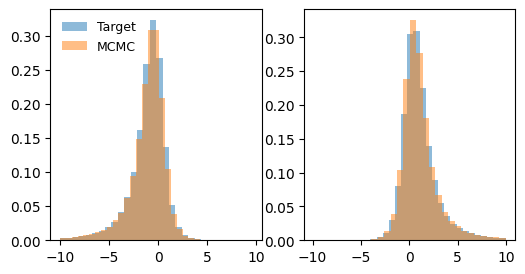

In [275]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Target')
ax[0].hist(mcmc_samples[abs(mcmc_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='MCMC')

ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)
ax[1].hist(mcmc_samples[abs(mcmc_samples[:, -1]) < 10, -1], 30, density=True, alpha=.5)

ax[0].legend(loc='upper left', fontsize=9, frameon=False)
plt.show()

In [276]:
jnp.quantile(exact_samples[:, 0], jnp.array([0.025, 0.975]))

Array([-7.625173 ,  1.6327397], dtype=float32)

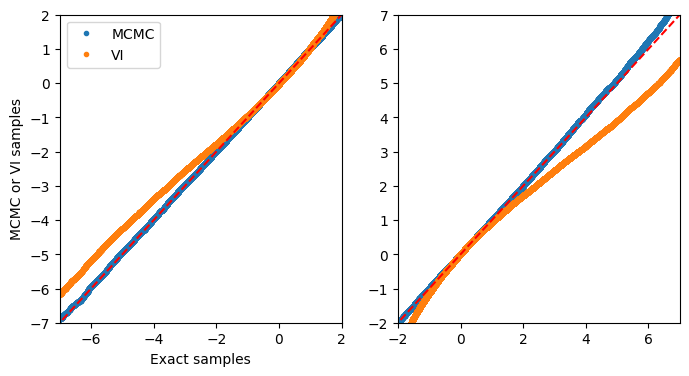

In [277]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i, j in enumerate([0, d-1]):
    exact_sorted = jnp.sort(exact_samples[:, j])
    mcmc_sorted = jnp.sort(mcmc_samples[:, j])
    vi_sorted = jnp.sort(vi_samples[:, j])
    ax[i].plot(exact_sorted, mcmc_sorted, '.', label='MCMC')
    ax[i].plot(exact_sorted, vi_sorted, '.', label='VI')
    ax[i].plot([-15, 15], [-15, 15], 'r--')  # Reference line for y=x

ax[0].set_xlim(-7., 2)
ax[0].set_ylim(-7., 2)
ax[1].set_xlim(-2., 7)
ax[1].set_ylim(-2., 7)
ax[0].set_xlabel('Exact samples')
ax[0].set_ylabel('MCMC or VI samples')
ax[0].legend()

## Banana t

In [278]:
from importlib import reload
import src.scp_core
reload(src.scp_core)
from src.scp_core import rwm_bright_side

In [305]:
from experiments.targets import Banana_t

d = 10
df = 2
target = Banana_t(df=df, d=d)

latitude = 1.5
scp_model = SCP(d=d, latitude=latitude)

params_scp = {
    'observer': jnp.zeros(d),
    'shift': jnp.zeros(d),
    'scale': 0.
}

seed = 0
n_train = 2000
X = uniform_sample_bright_side(d, latitude, jax.random.key(seed), n=n_train)

@jax.jit
def loss_fn(params):
    return scp_model.reverse_kl(params, target.log_prob, X)

opt_params, losses = train(loss_fn, params_scp, learning_rate=0.01, max_iter=1000)

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 2911.52it/s]


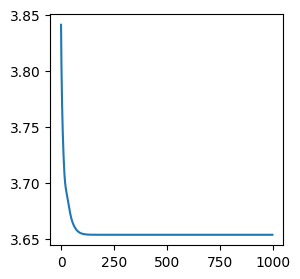

In [306]:
plt.figure(figsize=(3, 3))
plt.plot(losses)

In [307]:
scp_transformed_samples = scp_model.projection(opt_params, X)
exact_samples = target.sample(jax.random.key(1), n=X.shape[0])

(-10.0, 50.0)

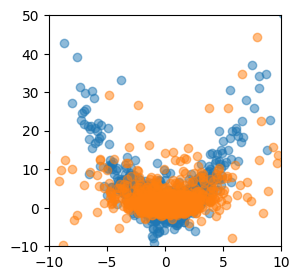

In [308]:
plt.figure(figsize=(3, 3))
plt.scatter(exact_samples[:, 0], exact_samples[:, 1], alpha=0.5, label='Exact')
plt.scatter(scp_transformed_samples[:, 0], scp_transformed_samples[:, 1], alpha=0.5)
plt.xlim(-10, 10)
plt.ylim(-10, 50)

heavy-tailed funnel, standard cauchy, skewed cauchy, cauchy difference prior, 



In [316]:
logp_sphere = scp_model.transform_target(target.log_prob, opt_params)

nsample = 1000_000
burnin = 500
x0 = uniform_sample_bright_side(d, latitude, jax.random.key(10), n=1)[0]
mcmc_samples_sphere, accepts = rwm_stepout_dark_side(logp_sphere, x0, latitude, key=jax.random.key(13), nsample=nsample+burnin, stepsize=5)
print(accepts.mean())

0.5716392


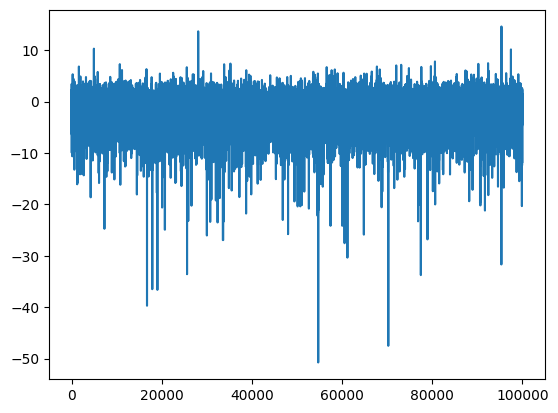

In [317]:
plt.plot(mcmc_samples[:, 0])

In [318]:
transformed_mcmc_samples = scp_model.projection(opt_params, mcmc_samples_sphere[burnin:])
transformed_mcmc_samples = transformed_mcmc_samples[::10]

(-10.0, 50.0)

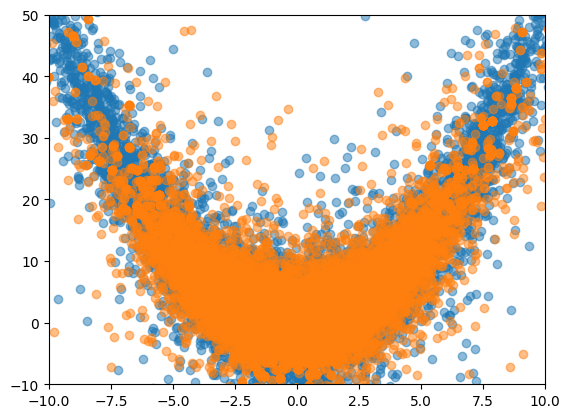

In [319]:
plt.scatter(exact_samples[:, 0], exact_samples[:, 1], alpha=0.5, label='Exact')
plt.scatter(transformed_mcmc_samples[:, 0], transformed_mcmc_samples[:, 1], alpha=0.5, label='MCMC')
plt.xlim(-10, 10)
plt.ylim(-10, 50)

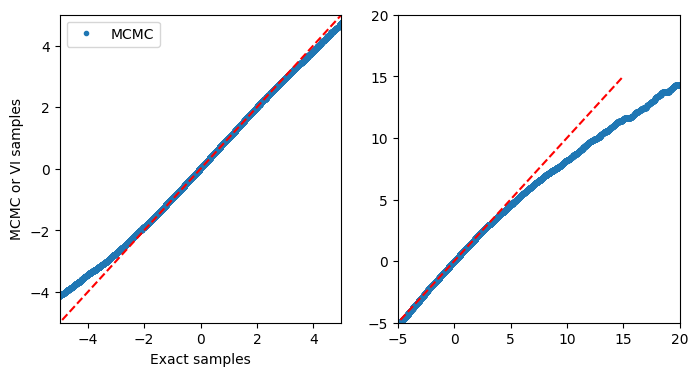

In [320]:
exact_samples = target.sample(jax.random.key(1), n=transformed_mcmc_samples.shape[0])
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i, j in enumerate([0, 1]):
    exact_sorted = jnp.sort(exact_samples[:, j])
    mcmc_sorted = jnp.sort(transformed_mcmc_samples[:, j])
    ax[i].plot(exact_sorted, mcmc_sorted, '.', label='MCMC')
    ax[i].set_xlim(jnp.quantile(exact_samples[:, j], jnp.array([0.01, 0.99])))
    ax[i].set_ylim(jnp.quantile(exact_samples[:, j], jnp.array([0.01, 0.99])))
    ax[i].plot([-15, 15], [-15, 15], 'r--')  # Reference line for y=x

ax[0].set_xlim(-5., 5)
ax[0].set_ylim(-5., 5)
ax[1].set_xlim(-5, 20)
ax[1].set_ylim(-5, 20)
ax[0].set_xlabel('Exact samples')
ax[0].set_ylabel('MCMC or VI samples')
ax[0].legend()

In [314]:
for a in [1, 2, 3, 4, 5]:
    print('CDF at x =', a)
    print('exact:', '{:.3f}'.format(jnp.mean(exact_samples[:, 2] > a)), ', MCMC:', '{:.3}'.format(jnp.mean(transformed_mcmc_samples[:, 2] > a)))

CDF at x = 1
exact: 0.211 , MCMC: 0.21
CDF at x = 2
exact: 0.092 , MCMC: 0.0899
CDF at x = 3
exact: 0.047 , MCMC: 0.0455
CDF at x = 4
exact: 0.029 , MCMC: 0.0257
CDF at x = 5
exact: 0.019 , MCMC: 0.0157


In [315]:
for a in [3, 5, 10, 15, 20]:
    print('CDF at x =', a)
    print('exact:', '{:.3f}'.format(jnp.mean(exact_samples[:, 1] > a)), ', MCMC:', '{:.3}'.format(jnp.mean(transformed_mcmc_samples[:, 1] > a)))

CDF at x = 3
exact: 0.171 , MCMC: 0.161
CDF at x = 5
exact: 0.104 , MCMC: 0.0936
CDF at x = 10
exact: 0.052 , MCMC: 0.0394
CDF at x = 15
exact: 0.034 , MCMC: 0.0241
CDF at x = 20
exact: 0.025 , MCMC: 0.017


TODO:
- Competing methods: naive RWM, NUTS
- Metrics to evaluate
- Target distributions
- Tuning parameters: latitude, RWM step size
- Optimizing SCP and NF simultaneously